In [11]:
import ee
import geemap.core as geemap
from IPython.display import display


ee.Authenticate()
ee.Initialize(project='oatuh-441508')


m = geemap.Map(center=[37.5665, 126.9780], zoom=6)

# 1월 데이터
jan_2023_climate = (
    ee.ImageCollection('ECMWF/ERA5_LAND/MONTHLY_AGGR')
    .filterDate('2023-01', '2023-02')
    .first()
)

temperature = jan_2023_climate.select('temperature_2m')

vis_params = {
    'min': 250,
    'max': 310,
    'palette': ['blue', 'cyan', 'green', 'yellow', 'red']
}

m.add_layer(temperature, vis_params, '2m Temperature (Jan 2023)')
display(m)

Map(center=[37.5665, 126.978], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zo…

In [36]:
jan_2023_climate = (
    ee.ImageCollection('ECMWF/ERA5_LAND/MONTHLY_AGGR')
    .filterDate('2023-01', '2023-02')
    .first()
)
jan_2023_climate

In [4]:
m = geemap.Map(center=[30, 0], zoom=2)

vis_params = {
    'bands': ['temperature_2m'],
    'min': 229,
    'max': 304,
    'palette': 'inferno',
}
m.add_layer(jan_2023_climate, vis_params, 'Temperature (K)')
m

Map(center=[30, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…

In [5]:
cities = ee.FeatureCollection([
    ee.Feature(ee.Geometry.Point(10.75, 59.91), {'city': 'Oslo'}),
    ee.Feature(ee.Geometry.Point(-118.24, 34.05), {'city': 'Los Angeles'}),
    ee.Feature(ee.Geometry.Point(103.83, 1.33), {'city': 'Singapore'}),
])
cities

In [6]:
m.add_layer(cities, name='Cities')
m

Map(center=[30, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…

In [7]:
display(m)

Map(center=[30, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…

In [8]:
%pip install -q --upgrade altair
import altair as alt

Note: you may need to restart the kernel to use updated packages.


In [9]:
city_climates = jan_2023_climate.reduceRegions(cities, ee.Reducer.first())

city_climates_dataframe = ee.data.computeFeatures(
    {'expression': city_climates, 'fileFormat': 'PANDAS_DATAFRAME'}
)
city_climates_dataframe

,geo,city,dewpoint_temperature_2m,dewpoint_temperature_2m_max,dewpoint_temperature_2m_min,evaporation_from_bare_soil_max,evaporation_from_bare_soil_min,evaporation_from_bare_soil_sum,evaporation_from_open_water_surfaces_excluding_oceans_max,evaporation_from_open_water_surfaces_excluding_oceans_min,...,volumetric_soil_water_layer_1_min,volumetric_soil_water_layer_2,volumetric_soil_water_layer_2_max,volumetric_soil_water_layer_2_min,volumetric_soil_water_layer_3,volumetric_soil_water_layer_3_max,volumetric_soil_water_layer_3_min,volumetric_soil_water_layer_4,volumetric_soil_water_layer_4_max,volumetric_soil_water_layer_4_min
0,"{'type': 'Point', 'coordinates': [10.75, 59.91]}",Oslo,268.522069,277.052826,255.988235,2.328306e-10,-0.000028,-0.000109,6.047194e-07,-2.328306e-10,...,0.240875,0.277464,0.339737,0.242050,0.288395,0.312698,0.263550,0.283256,0.291718,0.269760
1,"{'type': 'Point', 'coordinates': [-118.24, 34....",Los Angeles,279.018688,286.388687,265.190689,2.328306e-10,-0.000191,-0.016581,1.587765e-05,-2.093231e-04,...,0.293442,0.378105,0.438995,0.267899,0.338553,0.410660,0.196136,0.217798,0.233704,0.208649
2,"{'type': 'Point', 'coordinates': [103.83, 1.33]}",Singapore,296.269420,298.315628,294.220779,0.000000e+00,-0.000365,-0.036704,1.164153e-10,-1.259167e-04,...,0.393356,0.436111,0.520004,0.405411,0.436325,0.519806,0.401047,0.496528,0.510345,0.489883


In [10]:
alt.Chart(city_climates_dataframe).mark_bar(size=100).encode(
    alt.X('city:N', sort='y', axis=alt.Axis(labelAngle=0), title='City'),
    alt.Y('temperature_2m:Q', title='Temperature (K)'),
    tooltip=[
        alt.Tooltip('city:N', title='City'),
        alt.Tooltip('temperature_2m:Q', title='Temperature (K)'),
    ],
).properties(title='January 2023 temperature for selected cities', width=500)

alt.Chart(...)

In [18]:
import ee
import geemap

# Earth Engine 인증 및 초기화
ee.Initialize(project='oatuh-441508')  # 본인의 GCP 프로젝트 ID로 수정

# 지도 객체 생성
m = geemap.Map(center=[37.5665, 126.9780], zoom=15)

# 중심점 및 ROI(관심 영역) 정의: 1.5km 반경
center = ee.Geometry.Point([126.9780, 37.5665])
roi = center.buffer(1500).bounds()

# Sentinel-2 SR 이미지 수집 (2023년 1월, 구름 5% 이하)
collection = (
    ee.ImageCollection('COPERNICUS/S2_SR')
    .filterBounds(center)
    .filterDate('2023-01-01', '2023-01-31')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 5))
)

# 여러 장의 이미지를 median(중앙값)으로 합성 → 노이즈 감소, 선명도 향상
median_image = collection.median().clip(roi)

# 시각화 파라미터 (Contrast stretch 조정 가능)
vis_params = {
    'min': 500,
    'max': 3500,
    'bands': ['B4', 'B3', 'B2']  # RGB
}

# 지도에 레이어 추가
m.add_layer(median_image, vis_params, 'Seoul Jan Median (High Quality)')
m

Map(center=[37.5665, 126.978], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDa…

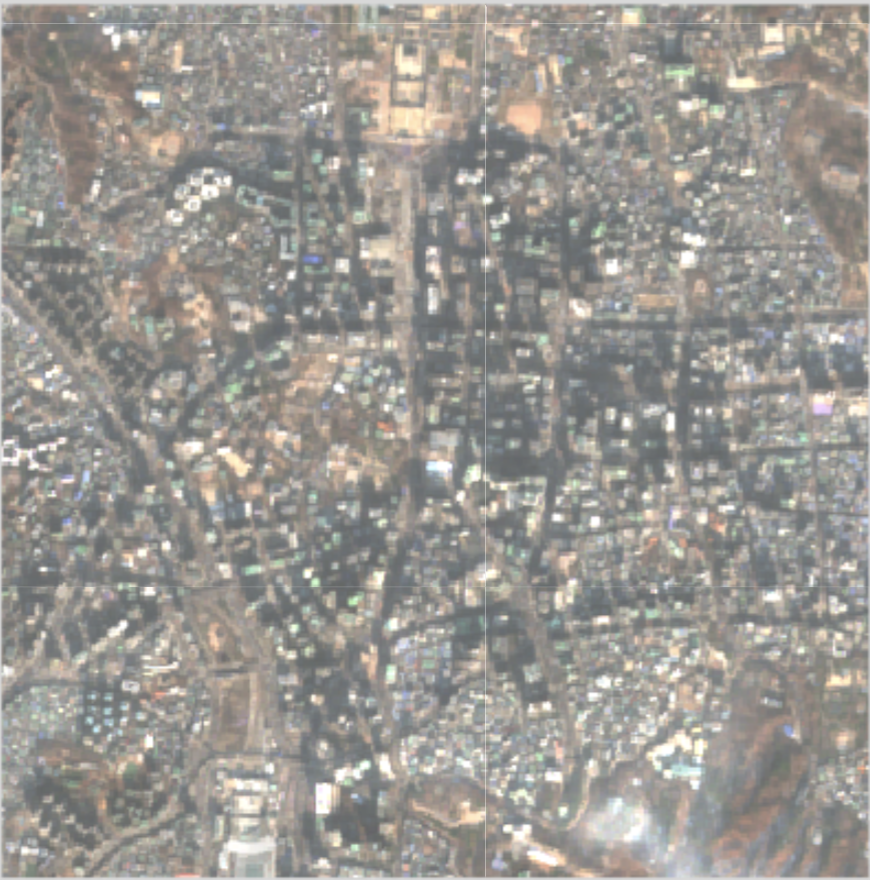

In [ ]:
# 필요한 라이브러리 불러오기
import ee  # Google Earth Engine 파이썬 API
import requests  # 웹 요청을 위한 라이브러리 (썸네일 이미지 다운로드에 사용)
from PIL import Image  # 이미지 파일을 열고 저장하기 위한 라이브러리
from io import BytesIO  # 이미지 바이트 데이터를 PIL로 읽기 위한 버퍼
from datetime import datetime, timedelta  # 날짜 처리용 (거래일 ± 범위 설정)

# -----------------------------------------------------------
# 1. Google Earth Engine 초기화
# -----------------------------------------------------------
# Earth Engine 계정 인증 이후에만 사용 가능
# 'project'는 본인의 GCP(Google Cloud Platform) 프로젝트 ID로 수정해야 함
ee.Initialize(project='oatuh-441508')

# -----------------------------------------------------------
# 2. 아파트 거래 데이터 예시 정의
# -----------------------------------------------------------
# 각 거래에 대해 위도(lat), 경도(lon), 거래일(date)를 포함
apt_transactions = [
    {'lat': 37.5665, 'lon': 126.9780, 'date': '2023-01-15'},  # 서울 중심
    {'lat': 35.1796, 'lon': 129.0756, 'date': '2023-01-05'},  # 부산 중심
    {'lat': 35.9078, 'lon': 127.7669, 'date': '2023-01-25'},  # 대한민국 중부
    # 추가 거래건도 이 리스트에 추가 가능
]

# -----------------------------------------------------------
# 3. 거래 데이터 하나씩 반복 처리
# -----------------------------------------------------------
for idx, tx in enumerate(apt_transactions):
    # 위도, 경도, 거래일자 추출
    lat = tx['lat']
    lon = tx['lon']
    tx_date = datetime.strptime(tx['date'], "%Y-%m-%d")  # 문자열 → datetime 객체

    # 거래일 기준으로 ±5일 범위 설정
    # Sentinel-2는 5일~10일 주기로 촬영하므로 여유 있는 범위 설정
    start_date = (tx_date - timedelta(days=5)).strftime('%Y-%m-%d')  # 예: '2023-01-10'
    end_date = (tx_date + timedelta(days=5)).strftime('%Y-%m-%d')    # 예: '2023-01-20'

    # -----------------------------------------------------------
    # 4. GEE에서 사용할 관심 영역(ROI) 설정
    # -----------------------------------------------------------
    # 위도/경도로 포인트 객체 생성
    center = ee.Geometry.Point([lon, lat])

    # 해당 지점을 중심으로 반경 1500m (1.5km) 버퍼 생성 → 이후 바운딩 박스로 ROI 설정
    roi = center.buffer(1500).bounds()

    # -----------------------------------------------------------
    # 5. Sentinel-2 SR 위성 이미지 컬렉션 필터링
    # -----------------------------------------------------------
    # Sentinel-2 SR은 지표면 반사율 보정이 된 고품질 이미지
    collection = (
        ee.ImageCollection('COPERNICUS/S2_SR')  # Sentinel-2 Surface Reflectance
        .filterBounds(center)  # 위도·경도 중심으로 이미지 필터링
        .filterDate(start_date, end_date)  # 거래일 기준 ±5일 범위
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 5))  # 구름 비율 5% 이하
    )

    # -----------------------------------------------------------
    # 6. 이미지 처리 및 시각화용 썸네일 요청
    # -----------------------------------------------------------
    try:
        # 여러 장의 이미지가 있을 경우 중간값 합성 → 노이즈 제거 + 선명도 증가
        image = collection.median().clip(roi)  # ROI 기준으로 자르기

        # GEE에서 썸네일 이미지용 URL 생성
        url = image.getThumbURL({
            'region': roi,  # 관심 영역 (1.5km 사각 영역)
            'dimensions': '224x224',  # 출력 이미지 크기 (딥러닝 모델 입력에 적합)
            'format': 'jpg',  # 출력 형식: JPEG
            'bands': ['B4', 'B3', 'B2'],  # RGB 밴드 선택 (B4: Red, B3: Green, B2: Blue)
            'min': 500,  # 밝기 조절 (스트레칭)
            'max': 3500
        })

        # 위에서 생성한 URL로 이미지 다운로드
        response = requests.get(url)
        img = Image.open(BytesIO(response.content))  # 이미지 바이트 → PIL 이미지로 변환

        # 이미지 저장 (파일명: apt_image_0.jpg, apt_image_1.jpg 등)
        img.save(f"apt_image_{idx}.jpg")

        # 저장 완료 메시지 출력
        print(f"[✓] 이미지 저장 완료: apt_image_{idx}.jpg")

    except Exception as e:
        # 예외 처리: 이미지가 없거나 다운로드 오류 시 메시지 출력
        print(f"[X] 이미지 실패 (index {idx}): {e}")